# Exploratory Data Analysis: Employee Review Text

Comprehensive text and sentiment analysis of employee reviews using visualization and statistical methods.

**Objectives**:
- Understand dataset composition and label distribution
- Analyze review text characteristics (length, vocabulary)
- Identify common themes by sentiment class
- Detect potential data quality issues
- Compare sentiment patterns across companies

## Imports

In [1]:
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
import os
from io import StringIO
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords', quiet=True)

print('All imports successful')

All imports successful


## Helper Classes

In [2]:
class TextEDA:
    """Exploratory Data Analysis for employee review text data."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.s3_client = boto3.client('s3', region_name='us-east-1')
        self.df_data = None
        self.set_plot_style()
    
    def set_plot_style(self):
        """Configure matplotlib/seaborn styling."""
        sns.set_style('whitegrid')
        plt.rcParams['figure.figsize'] = (14, 6)
        plt.rcParams['font.size'] = 11
    
    def import_data(self):
        """Load cleaned data from S3."""
        str_uri = f's3://{self.str_bucket}/00_data_collection/employee_reviews_clean.parquet'
        self.df_data = pd.read_parquet(str_uri)
        print(f'Loaded {len(self.df_data):,} reviews from S3')
        return True
    
    def get_df_info(self):
        """Print dataset information."""
        if self.df_data is None:
            print('Data not loaded. Call import_data() first.')
            return
        
        print('\n' + '='*60)
        print('DATASET OVERVIEW')
        print('='*60)
        print(f'Total reviews: {len(self.df_data):,}')
        print(f'Columns: {list(self.df_data.columns)}')
        print(f'\nData types:')
        print(self.df_data.dtypes)
        print(f'\nMissing values:')
        print(self.df_data.isnull().sum())
        print(f'\nMemory usage: {self.df_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
    
    def plot_rating_distribution(self):
        """Plot distribution of star ratings."""
        if self.df_data is None:
            return
        
        fig, ax = plt.subplots(figsize=(10, 6))
        dict_rating_counts = self.df_data['overall_rating'].value_counts().sort_index()
        dict_rating_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_xlabel('Star Rating', fontsize=12, fontweight='bold')
        ax.set_ylabel('Count', fontsize=12, fontweight='bold')
        ax.set_title('Distribution of Overall Ratings', fontsize=14, fontweight='bold')
        ax.set_xticklabels(dict_rating_counts.index, rotation=0)
        
        # Add value labels on bars
        for int_i, int_v in enumerate(dict_rating_counts.values):
            ax.text(int_i, int_v + max(dict_rating_counts.values)*0.01, str(int_v), 
                   ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_rating_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 01_rating_distribution.png')
    
    def plot_sentiment_distribution(self):
        """Plot distribution of sentiment labels (3-class and binary)."""
        if self.df_data is None:
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 3-class sentiment
        dict_3class = self.df_data['sentiment_3class'].value_counts().sort_index()
        list_labels_3class = ['Negative', 'Neutral', 'Positive']
        list_colors = ['#d62728', '#ff7f0e', '#2ca02c']
        
        axes[0].bar(range(len(dict_3class)), dict_3class.values, color=list_colors, edgecolor='black')
        axes[0].set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
        axes[0].set_title('3-Class Sentiment Distribution', fontsize=13, fontweight='bold')
        axes[0].set_xticks(range(len(dict_3class)))
        axes[0].set_xticklabels(list_labels_3class)
        
        for int_i, int_v in enumerate(dict_3class.values):
            axes[0].text(int_i, int_v + max(dict_3class.values)*0.01, str(int_v), 
                        ha='center', va='bottom', fontweight='bold')
        
        # Binary sentiment
        dict_binary = self.df_data['sentiment_binary'].value_counts().sort_index()
        list_labels_binary = ['Negative', 'Positive']
        list_colors_binary = ['#d62728', '#2ca02c']
        
        axes[1].bar(range(len(dict_binary)), dict_binary.values, color=list_colors_binary, edgecolor='black')
        axes[1].set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Count', fontsize=12, fontweight='bold')
        axes[1].set_title('Binary Sentiment Distribution', fontsize=13, fontweight='bold')
        axes[1].set_xticks(range(len(dict_binary)))
        axes[1].set_xticklabels(list_labels_binary)
        
        for int_i, int_v in enumerate(dict_binary.values):
            axes[1].text(int_i, int_v + max(dict_binary.values)*0.01, str(int_v), 
                        ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_sentiment_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 02_sentiment_distribution.png')
    
    def plot_review_length_distribution(self):
        """Plot histogram of review text lengths."""
        if self.df_data is None:
            return
        
        self.df_data['review_length'] = self.df_data['review_text'].str.len()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.hist(self.df_data['review_length'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
        ax.axvline(self.df_data['review_length'].mean(), color='red', linestyle='--', 
                   linewidth=2, label=f'Mean: {self.df_data["review_length"].mean():.0f}')
        ax.axvline(self.df_data['review_length'].median(), color='green', linestyle='--', 
                   linewidth=2, label=f'Median: {self.df_data["review_length"].median():.0f}')
        
        ax.set_xlabel('Review Length (characters)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title('Distribution of Review Text Lengths', fontsize=14, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/03_review_length_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 03_review_length_distribution.png')
    
    def plot_word_frequency(self, int_top_n=30):
        """Plot top N words in reviews (after stopword removal)."""
        if self.df_data is None:
            return
        
        # Tokenize and remove stopwords
        set_stopwords = set(stopwords.words('english'))
        list_all_words = []
        
        for str_text in self.df_data['review_text']:
            list_words = str_text.lower().split()
            for str_word in list_words:
                # Simple cleaning
                str_word = ''.join(c for c in str_word if c.isalnum())
                if str_word and str_word not in set_stopwords and len(str_word) > 2:
                    list_all_words.append(str_word)
        
        # Get top N words
        dict_word_counts = Counter(list_all_words)
        list_top_words = dict(dict_word_counts.most_common(int_top_n))
        
        fig, ax = plt.subplots(figsize=(12, 8))
        list_words = list(list_top_words.keys())
        list_counts = list(list_top_words.values())
        
        ax.barh(list_words, list_counts, color='steelblue', edgecolor='black')
        ax.set_xlabel('Frequency', fontsize=12, fontweight='bold')
        ax.set_title(f'Top {int_top_n} Most Frequent Words in Reviews', fontsize=14, fontweight='bold')
        ax.invert_yaxis()
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/04_word_frequency.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 04_word_frequency.png')
    
    def plot_word_frequency_by_sentiment(self, int_top_n=15):
        """Plot top words per sentiment class."""
        if self.df_data is None:
            return
        
        set_stopwords = set(stopwords.words('english'))
        list_labels = ['Negative', 'Neutral', 'Positive']
        list_colors = ['#d62728', '#ff7f0e', '#2ca02c']
        
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for int_label in [0, 1, 2]:
            df_sentiment = self.df_data[self.df_data['sentiment_3class'] == int_label]
            list_words = []
            
            for str_text in df_sentiment['review_text']:
                list_words_temp = str_text.lower().split()
                for str_word in list_words_temp:
                    str_word = ''.join(c for c in str_word if c.isalnum())
                    if str_word and str_word not in set_stopwords and len(str_word) > 2:
                        list_words.append(str_word)
            
            dict_counts = Counter(list_words)
            list_top = dict(dict_counts.most_common(int_top_n))
            
            axes[int_label].barh(list(list_top.keys()), list(list_top.values()), 
                                 color=list_colors[int_label], edgecolor='black')
            axes[int_label].set_title(f'{list_labels[int_label]} Reviews', fontsize=12, fontweight='bold')
            axes[int_label].set_xlabel('Frequency', fontsize=10, fontweight='bold')
            axes[int_label].invert_yaxis()
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/05_word_frequency_by_sentiment.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 05_word_frequency_by_sentiment.png')
    
    def plot_review_length_by_sentiment(self):
        """Box plot of review length by sentiment class."""
        if self.df_data is None:
            return
        
        if 'review_length' not in self.df_data.columns:
            self.df_data['review_length'] = self.df_data['review_text'].str.len()
        
        fig, ax = plt.subplots(figsize=(12, 6))
        
        list_labels = ['Negative', 'Neutral', 'Positive']
        list_data = [self.df_data[self.df_data['sentiment_3class'] == i]['review_length'].values for i in [0, 1, 2]]
        
        bp = ax.boxplot(list_data, labels=list_labels, patch_artist=True)
        list_colors = ['#d62728', '#ff7f0e', '#2ca02c']
        for patch, str_color in zip(bp['boxes'], list_colors):
            patch.set_facecolor(str_color)
            patch.set_alpha(0.7)
        
        ax.set_ylabel('Review Length (characters)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Sentiment Class', fontsize=12, fontweight='bold')
        ax.set_title('Review Length Distribution by Sentiment', fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/06_review_length_by_sentiment.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 06_review_length_by_sentiment.png')
    
    def plot_company_sentiment(self):
        """Sentiment distribution by company."""
        if self.df_data is None:
            return
        
        df_company_sentiment = pd.crosstab(self.df_data['company_name'], 
                                           self.df_data['sentiment_3class'])
        df_company_sentiment.columns = ['Negative', 'Neutral', 'Positive']
        
        # Normalize to percentages
        df_company_pct = df_company_sentiment.div(df_company_sentiment.sum(axis=1), axis=0) * 100
        
        fig, ax = plt.subplots(figsize=(12, 6))
        df_company_pct.plot(kind='bar', stacked=True, ax=ax, 
                            color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='black')
        ax.set_xlabel('Company', fontsize=12, fontweight='bold')
        ax.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
        ax.set_title('Sentiment Distribution by Company', fontsize=14, fontweight='bold')
        ax.legend(title='Sentiment', fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/07_company_sentiment.png', bbox_inches='tight', dpi=150)
        plt.show()
        print('Saved: 07_company_sentiment.png')

## Constants

In [3]:
# S3 Configuration
str_bucket = 'nlp-sentiment-analysis-demo'
str_task = '01_eda'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
    print(f'✓ Created output directory: {str_dirname_output}')
except FileExistsError:
    print(f'✓ Output directory already exists: {str_dirname_output}')

✓ Output directory already exists: ./output


## Load and Explore Data

In [5]:
# Initialize EDA class
cls_eda = TextEDA(str_bucket, str_dirname_output)

# Load data
cls_eda.import_data()

# Display info
cls_eda.get_df_info()

Loaded 30,281 reviews from S3

DATASET OVERVIEW
Total reviews: 30,281
Columns: ['company_name', 'overall_rating', 'review_text', 'sentiment_3class', 'sentiment_binary']

Data types:
company_name        object
overall_rating       int64
review_text         object
sentiment_3class     int64
sentiment_binary     int64
dtype: object

Missing values:
company_name        0
overall_rating      0
review_text         0
sentiment_3class    0
sentiment_binary    0
dtype: int64

Memory usage: 14.20 MB


## Show Data

In [6]:
cls_eda.df_data

,company_name,overall_rating,review_text,sentiment_3class,sentiment_binary
0,Unknown,5,People are smart and friendly Bureaucracy is s...,2,1
1,Unknown,5,"1) Food, food, food. 15+ cafes on main campus ...",2,1
2,Unknown,5,"* If you're a software engineer, you're among ...",2,1
3,Unknown,4,You can't find a more well-regarded company th...,2,1
4,Unknown,4,Impact driven. Best tech in the world. Size ma...,2,1
...,...,...,...,...,...
30276,Unknown,2,MS is a good company but hire wrong people. Wo...,0,0
30277,Unknown,4,"Good benefits package, huge customer base. Pol...",2,1
30278,Unknown,3,"-Access to a wide range of technologies, compl...",1,0
30279,Unknown,4,Nice place to work. Good atmosphere with advan...,2,1


## Rating and Sentiment Analysis

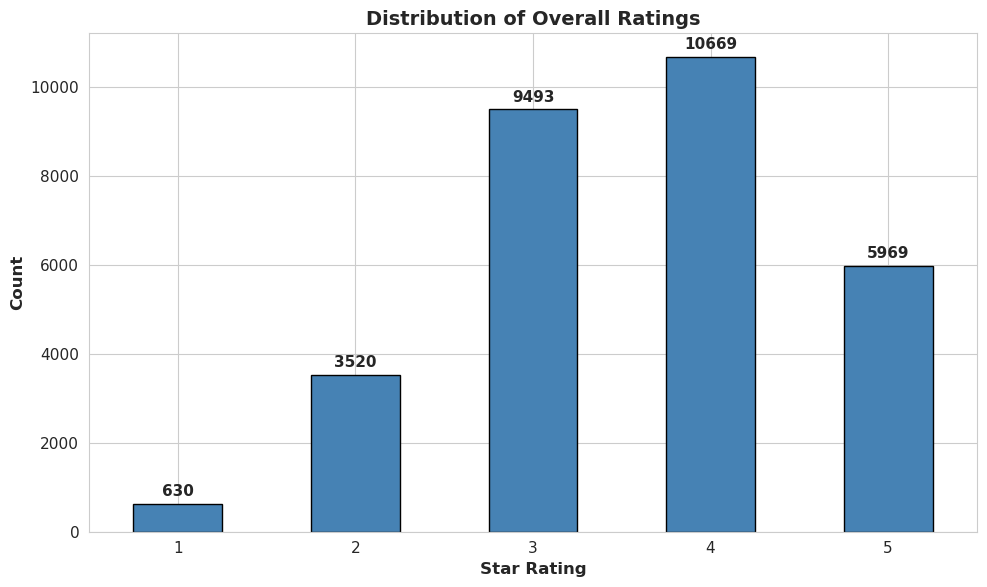

Saved: 01_rating_distribution.png


In [7]:
# Plot rating distribution
cls_eda.plot_rating_distribution()

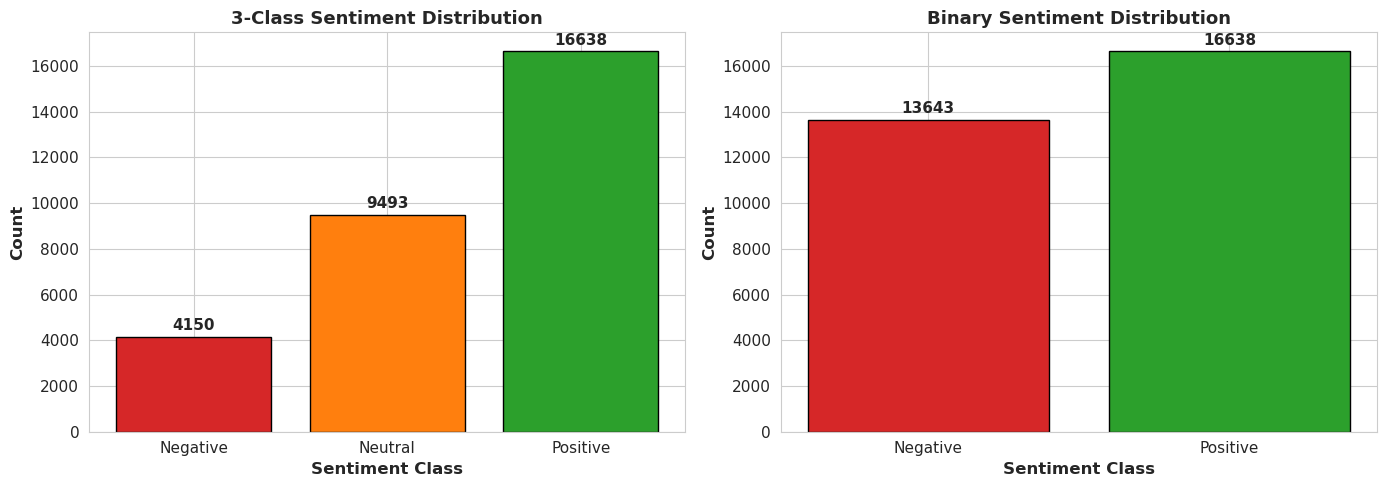

Saved: 02_sentiment_distribution.png


In [8]:
# Plot sentiment labels
cls_eda.plot_sentiment_distribution()

## Text Characteristics

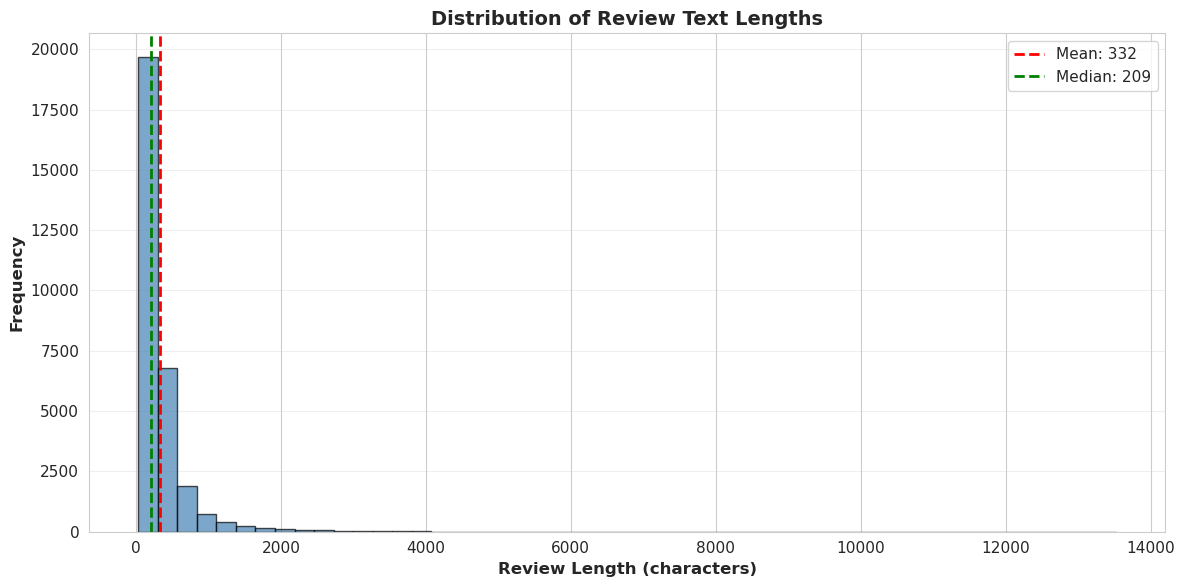

Saved: 03_review_length_distribution.png


In [9]:
# Review length analysis
cls_eda.plot_review_length_distribution()

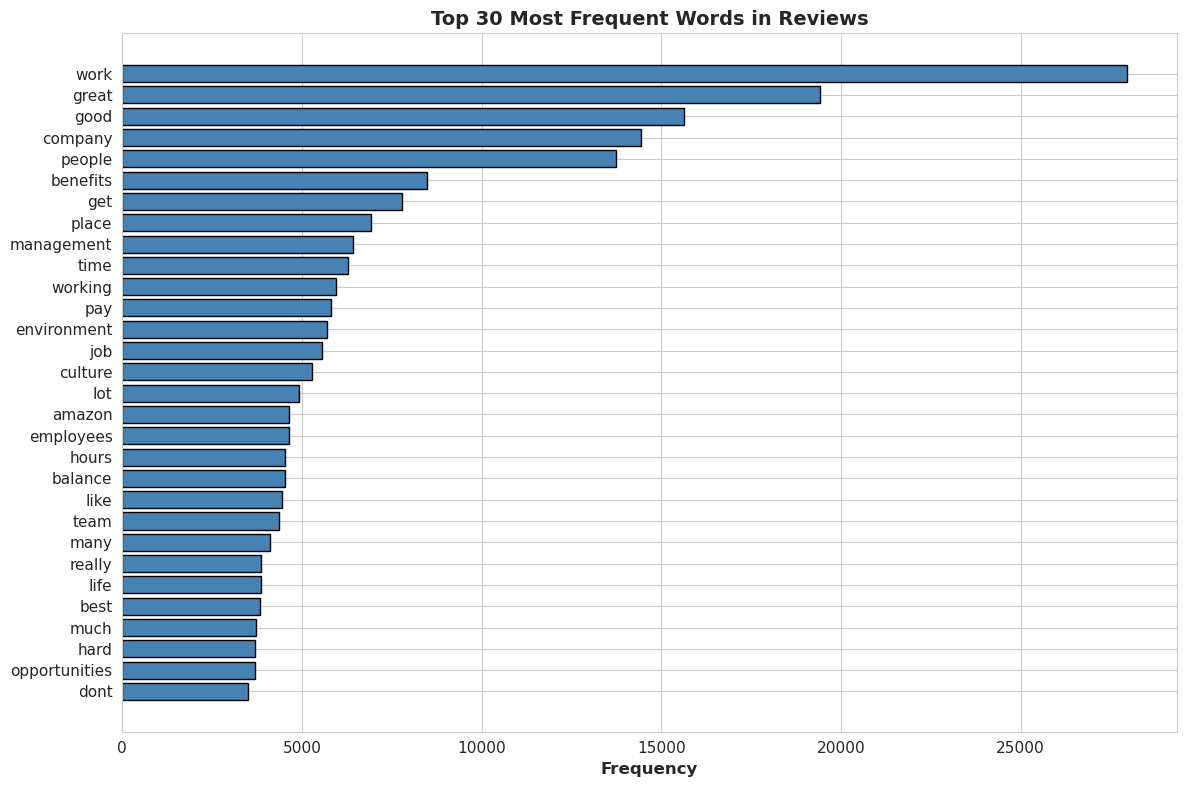

Saved: 04_word_frequency.png


In [10]:
# Word frequency analysis
cls_eda.plot_word_frequency(int_top_n=30)

## Sentiment-Specific Analysis

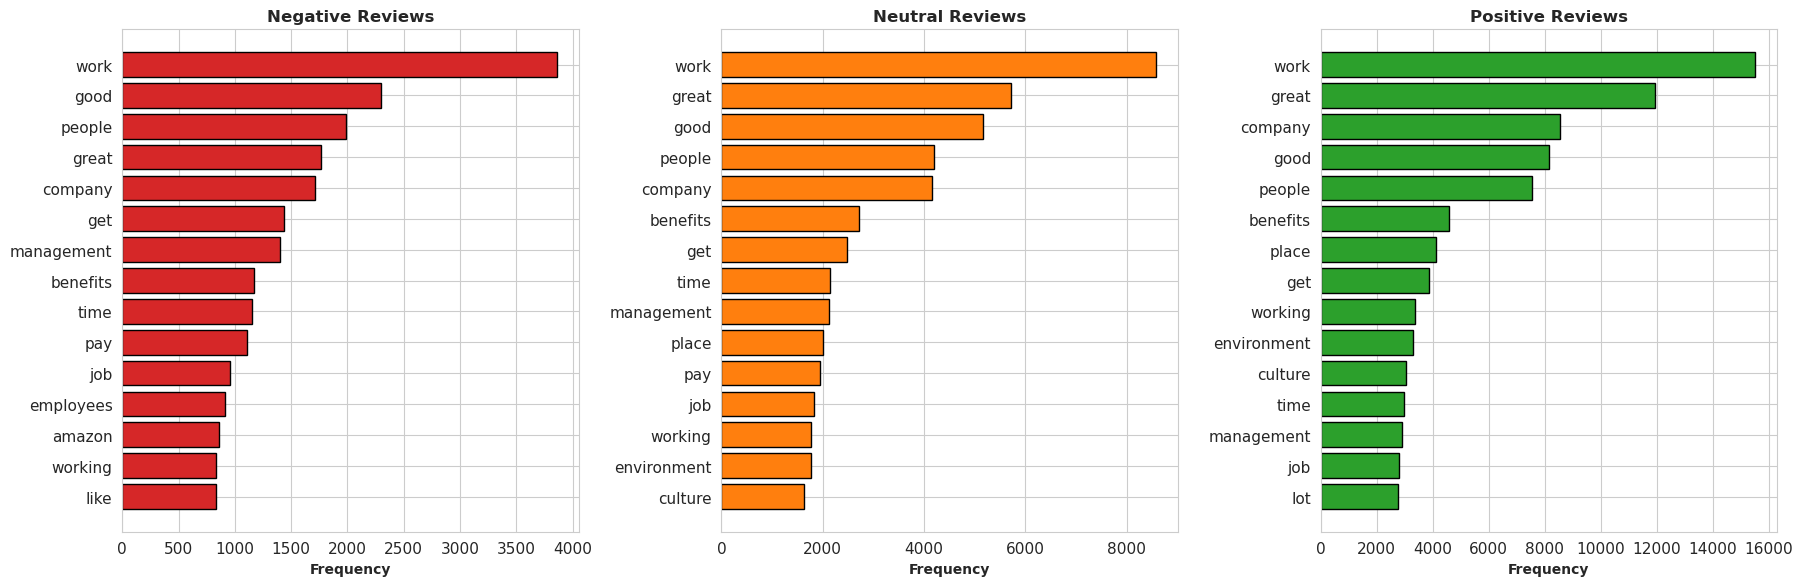

Saved: 05_word_frequency_by_sentiment.png


In [11]:
# Words by sentiment class
cls_eda.plot_word_frequency_by_sentiment(int_top_n=15)

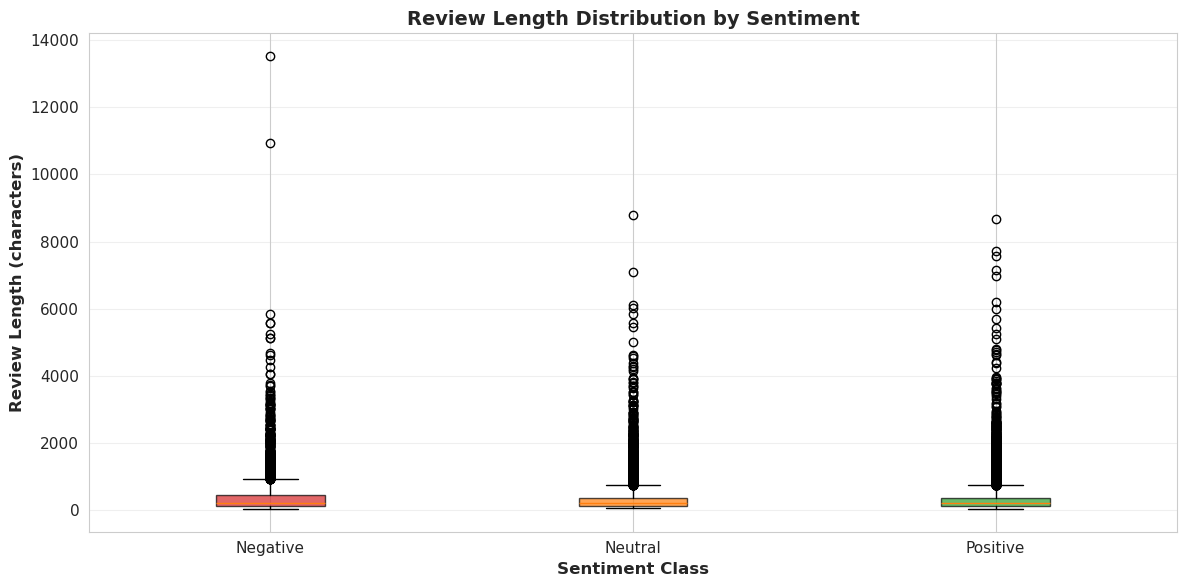

Saved: 06_review_length_by_sentiment.png


In [12]:
# Review length by sentiment
cls_eda.plot_review_length_by_sentiment()

## Company Analysis

# Sentiment distribution by company

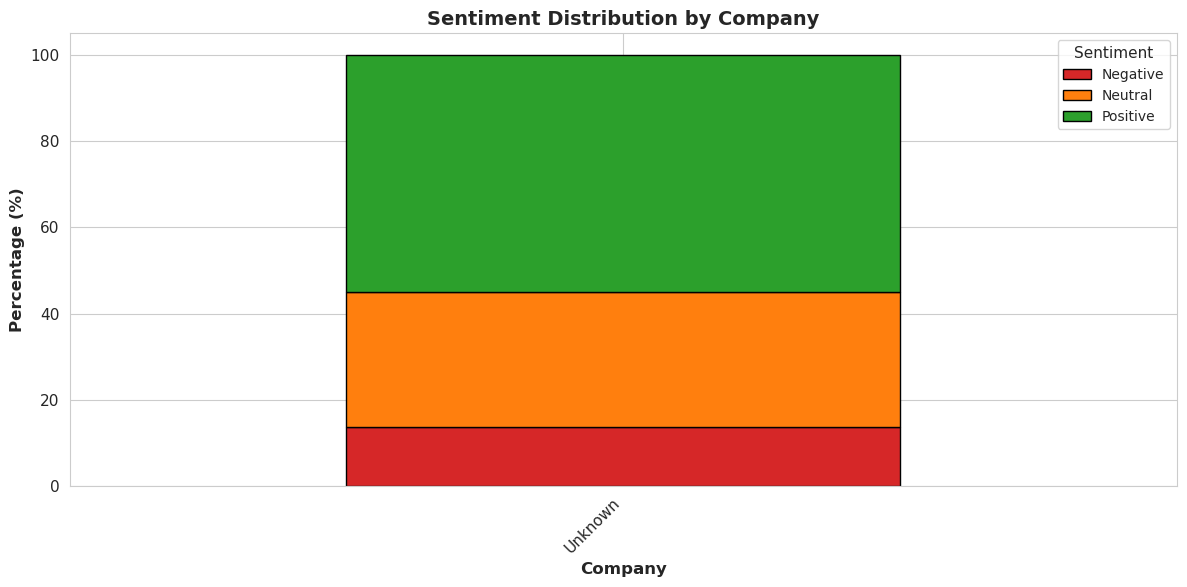

Saved: 07_company_sentiment.png


In [13]:
cls_eda.plot_company_sentiment()

## EDA Summary

In [14]:
print('\n' + '='*60)
print('EXPLORATORY DATA ANALYSIS SUMMARY')
print('='*60)

df_data = cls_eda.df_data

if 'review_length' not in df_data.columns:
    df_data['review_length'] = df_data['review_text'].str.len()

print(f'\nDataset Size: {len(df_data):,} reviews')
print(f'Number of Companies: {df_data["company_name"].nunique()}')
print(f'\nRating Statistics:')
print(f'  Mean rating: {df_data["overall_rating"].mean():.2f}')
print(f'  Median rating: {df_data["overall_rating"].median():.1f}')
print(f'  Std dev: {df_data["overall_rating"].std():.2f}')

print(f'\nReview Length Statistics:')
print(f'  Mean: {df_data["review_length"].mean():.0f} characters')
print(f'  Median: {df_data["review_length"].median():.0f} characters')
print(f'  Min: {df_data["review_length"].min():.0f} characters')
print(f'  Max: {df_data["review_length"].max():.0f} characters')

print(f'\nSentiment Distribution (3-class):')
list_labels = ['Negative', 'Neutral', 'Positive']
for int_i, str_label in enumerate(list_labels):
    int_count = (df_data['sentiment_3class'] == int_i).sum()
    flt_pct = (int_count / len(df_data)) * 100
    print(f'  {str_label}: {int_count:,} ({flt_pct:.1f}%)')

print(f'\nSentiment Distribution (Binary):')
list_labels_binary = ['Negative', 'Positive']
for int_i, str_label in enumerate(list_labels_binary):
    int_count = (df_data['sentiment_binary'] == int_i).sum()
    flt_pct = (int_count / len(df_data)) * 100
    print(f'  {str_label}: {int_count:,} ({flt_pct:.1f}%)')

print(f'\nReviews by Company:')
for str_company, int_count in df_data['company_name'].value_counts().items():
    flt_pct = (int_count / len(df_data)) * 100
    print(f'  {str_company}: {int_count:,} ({flt_pct:.1f}%)')

print(f'\nOutput Visualizations: {len(os.listdir(str_dirname_output))} files saved to {str_dirname_output}/')
print('='*60)


EXPLORATORY DATA ANALYSIS SUMMARY

Dataset Size: 30,281 reviews
Number of Companies: 1

Rating Statistics:
  Mean rating: 3.59
  Median rating: 4.0
  Std dev: 1.00

Review Length Statistics:
  Mean: 332 characters
  Median: 209 characters
  Min: 28 characters
  Max: 13528 characters

Sentiment Distribution (3-class):
  Negative: 4,150 (13.7%)
  Neutral: 9,493 (31.3%)
  Positive: 16,638 (54.9%)

Sentiment Distribution (Binary):
  Negative: 13,643 (45.1%)
  Positive: 16,638 (54.9%)

Reviews by Company:
  Unknown: 30,281 (100.0%)

Output Visualizations: 8 files saved to ./output/
